In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import entropy

from utils import (
    DATADIR,
    FIGURESDIR,
    Normalizer,
    TransitionMatrix,
    load_events,
    setup_scienceplots,
)

setup_scienceplots()

In [3]:
df = pl.concat(
    [
        pl.read_csv(file)
        for file in DATADIR.rglob("event_metadata.csv")
        if not pl.read_csv(file).is_empty()
    ]
)
intensities = dict(
    map(
        lambda item: (item["#"], int(float(item["class"][1:]))),
        df[["#", "class"]].to_dicts(),
    )
)

In [ ]:
event_data = load_events(custom_scale_args=intensities)  # type: ignore

In [6]:
events_df = pl.DataFrame(event_data, schema=["event_class", "event_intensity", "transition_matrix", "tm_technique", "normalizer"])

# Linear algebra features
eigenvalues = [
    np.linalg.eigvals(nx.adjacency_matrix(g).toarray())
    for g in events_df["transition_matrix"]
]
traces = [
    np.linalg.trace(nx.adjacency_matrix(g).toarray())
    for g in events_df["transition_matrix"]
]

# For entropies could be a good idea to get the average, but I'll keep the list for now
entropies = [
    entropy(nx.adjacency_matrix(G).toarray(), axis=1)
    for G in events_df["transition_matrix"]
]

# Eigenvector centrality {'G1': ..., 'G2': ..., 'G3': ...}
eigenvector_centralities = [
    nx.eigenvector_centrality_numpy(g) for g in events_df["transition_matrix"]
]

events_df = events_df.with_columns(
    pl.Series("eigenvalues", eigenvalues, dtype=pl.Object),
    pl.Series("traces", traces),
    pl.Series("entropies", entropies, dtype=pl.Object),
    pl.Series("eigenvector_centralities", eigenvector_centralities, dtype=pl.Object),
)

events_df

event_class,event_intensity,transition_matrix,tm_technique,normalizer,eigenvalues,traces,entropies,eigenvector_centralities
str,f64,object,str,str,object,f64,object,object
"""M""",2.5,DiGraph with 3 nodes and 9 edges,"""before""","""custom""",[ 1. 0.13710526 -0.01644345],1.120662,[1.04303238 1.09504922 1.0929078 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",2.5,DiGraph with 3 nodes and 9 edges,"""before""","""min_max""",[ 1. 0.13710526 -0.01644345],1.120662,[1.04303238 1.09504922 1.0929078 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",2.5,DiGraph with 3 nodes and 9 edges,"""before""","""z_score""",[ 1. 0.13710526 -0.01644345],1.120662,[1.04303238 1.09504922 1.0929078 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",2.5,DiGraph with 3 nodes and 9 edges,"""before""","""robust""",[ 1. 0.13710526 -0.01644345],1.120662,[1.04303238 1.09504922 1.0929078 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""M""",2.5,DiGraph with 3 nodes and 9 edges,"""before""","""decimal_scaling""",[ 1. 0.13710526 -0.01644345],1.120662,[1.04303238 1.09504922 1.0929078 ],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
…,…,…,…,…,…,…,…,…
"""X""",1.1,DiGraph with 3 nodes and 9 edges,"""all""","""min_max""",[ 1. 0.58913987 -0.11988859],1.469251,[0.10463773 1.07691931 1.07768174],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""X""",1.1,DiGraph with 3 nodes and 9 edges,"""all""","""z_score""",[ 1. 0.58913987 -0.11988859],1.469251,[0.10463773 1.07691931 1.07768174],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"
"""X""",1.1,DiGraph with 3 nodes and 9 edges,"""all""","""robust""",[ 1. 0.58913987 -0.11988859],1.469251,[0.10463773 1.07691931 1.07768174],"{'G1': 0.5773502691896258, 'G2': 0.5773502691896258, 'G3': 0.5773502691896258}"


In [8]:
normalizers = events_df["normalizer"].unique().to_list()
for normalizer in normalizers:
    subset = events_df.filter(pl.col("normalizer") == normalizer)
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    plot_data = subset.to_pandas()
    plot_data = plot_data.sort_values("event_class")

    sns.boxplot(
        data=plot_data, x="event_class", y="traces", hue="tm_technique", ax=axes[0, 0]
    )
    sns.boxplot(
        data=plot_data,
        x="event_class",
        y=plot_data["eigenvalues"].apply(lambda x: np.mean(np.abs(x))),
        hue="tm_technique",
        ax=axes[0, 1],
    )
    sns.boxplot(
        data=plot_data,
        x="event_class",
        y=plot_data["entropies"].apply(lambda x: np.mean(x)),
        hue="tm_technique",
        ax=axes[1, 0],
    )
    sns.boxplot(
        data=plot_data,
        x="event_class",
        y=plot_data["eigenvector_centralities"].apply(
            lambda x: np.mean(list(x.values()))
        ),
        hue="tm_technique",
        ax=axes[1, 1],
    )

    plt.suptitle(f"Boxplots of features by event class and TM technique (Normalizer: {normalizer})")
    plt.tight_layout()
    plt.savefig(FIGURESDIR / "boxplots" / f"normalizer_{normalizer}.png")
    plt.close()

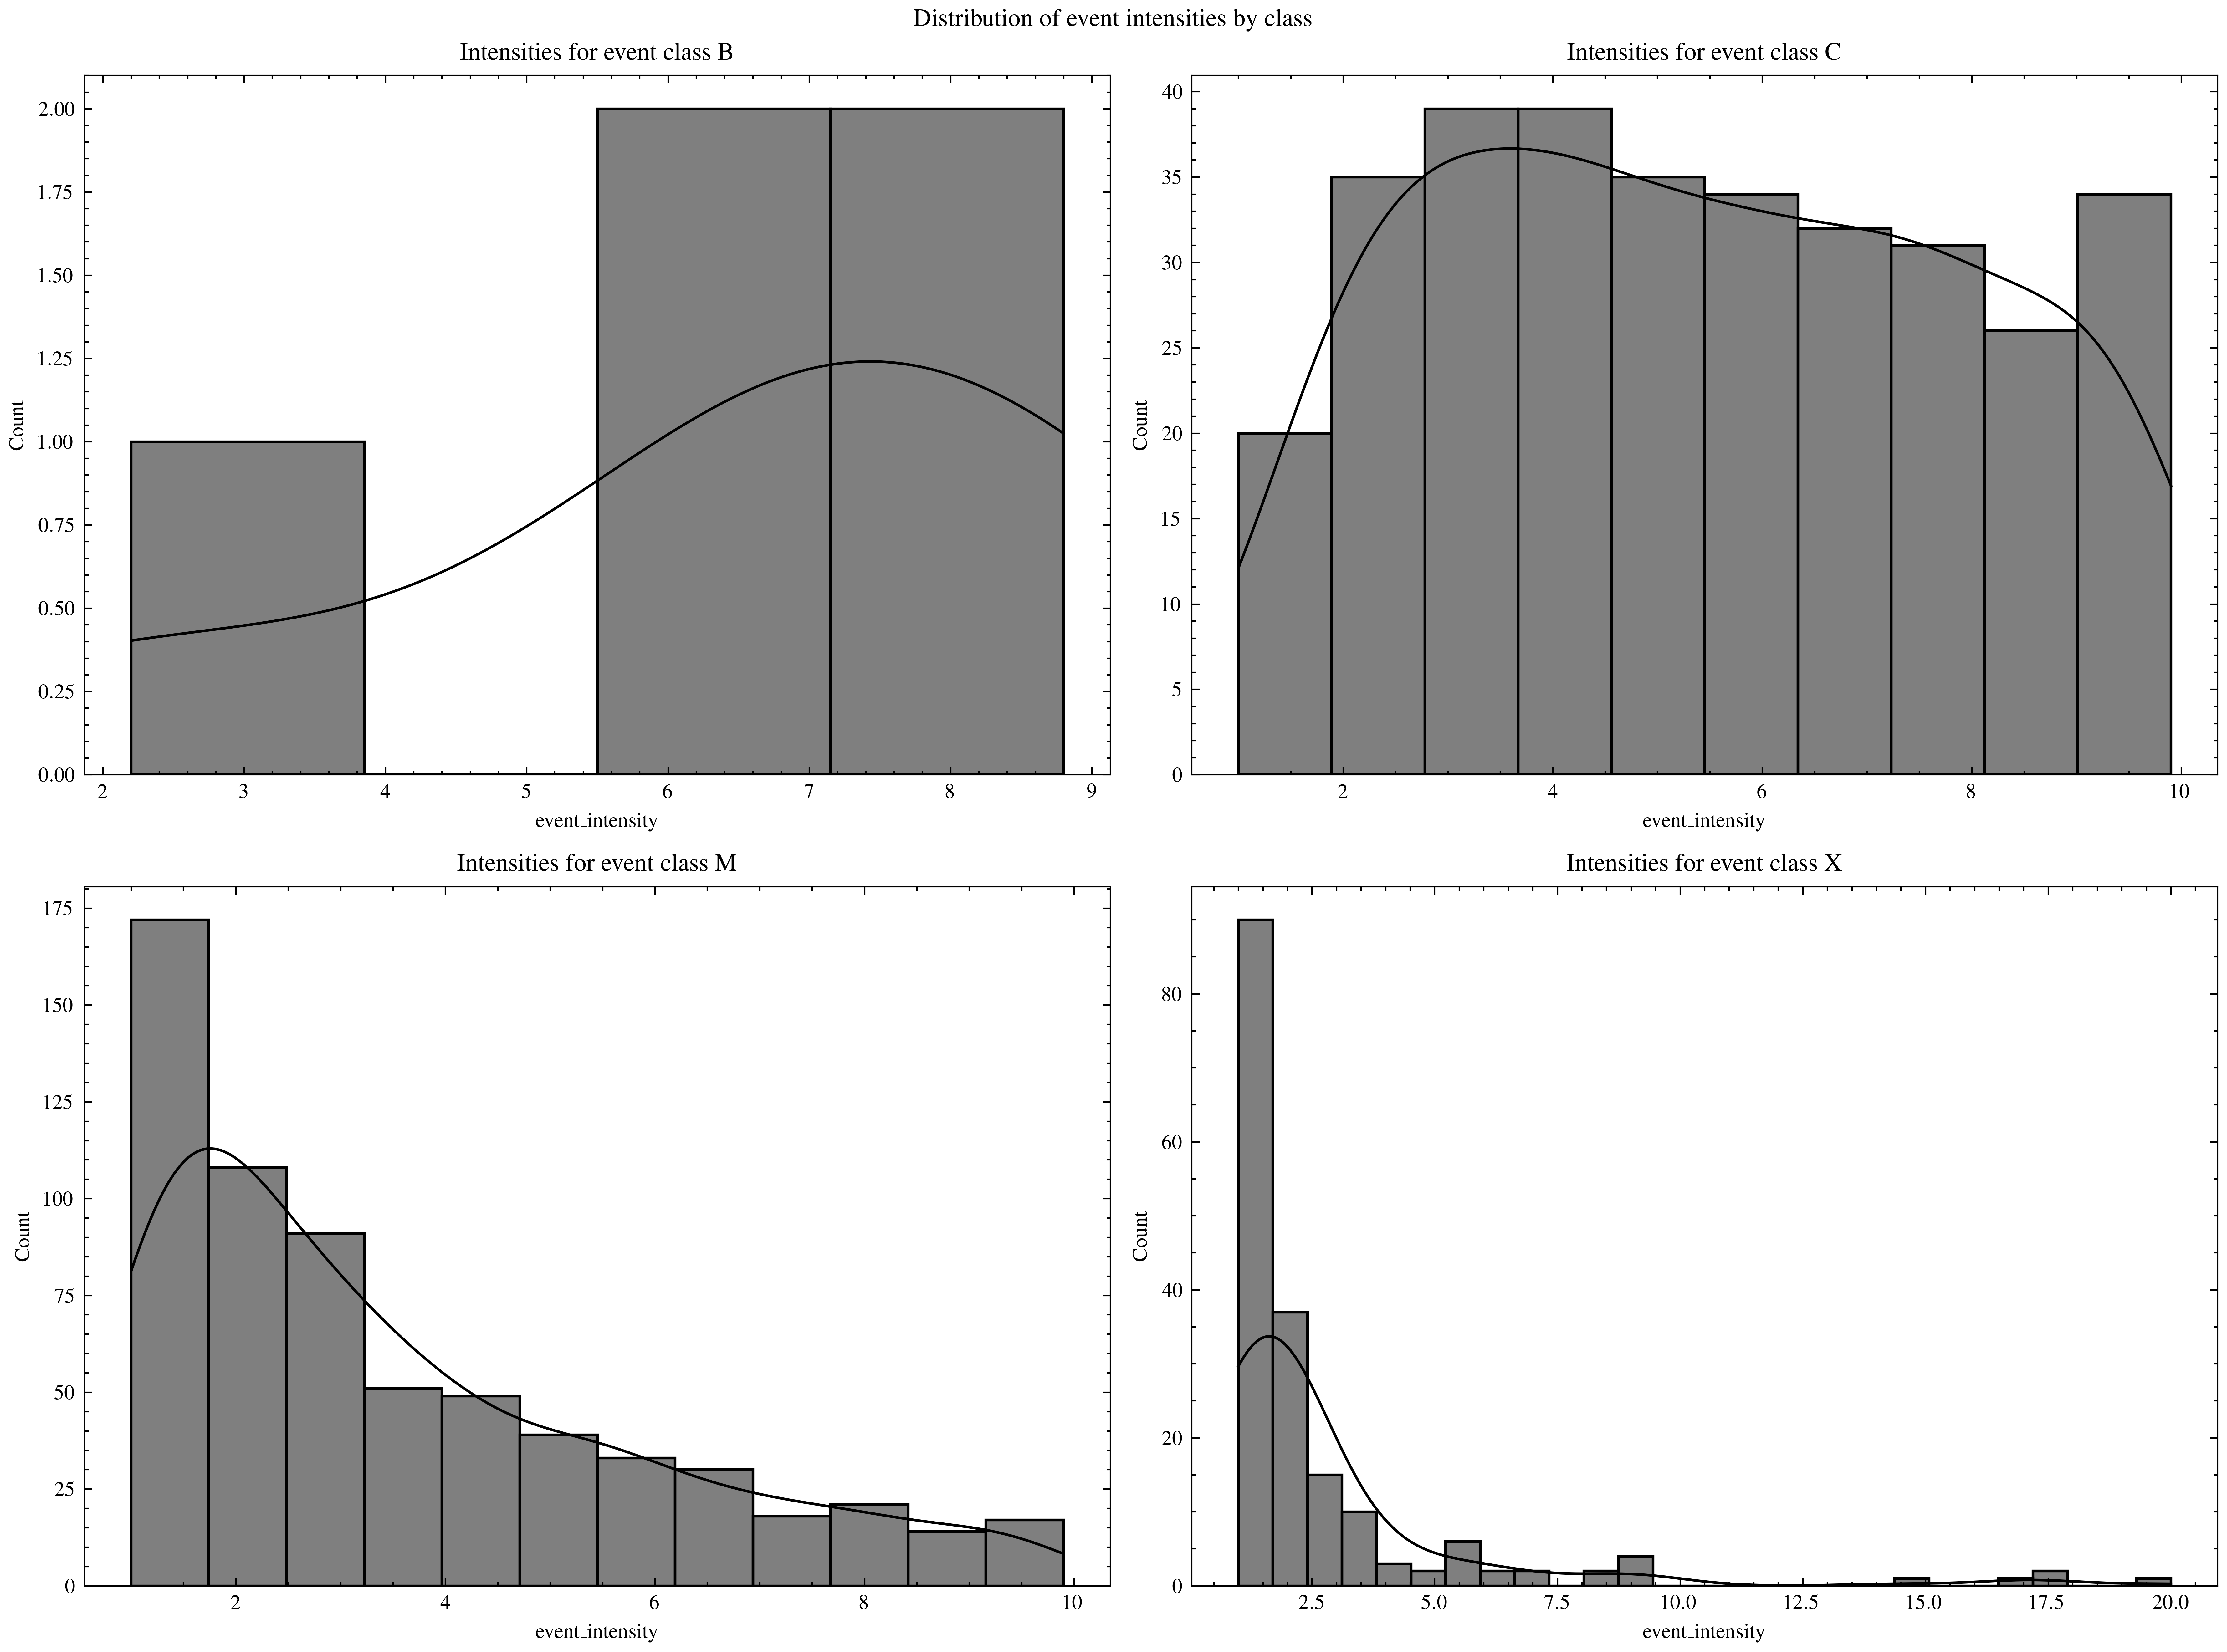

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

event_classes = sorted(events_df["event_class"].unique().to_list())
base_df = events_df.filter(
    pl.col("normalizer") == Normalizer.NONE,
    pl.col("tm_technique") == TransitionMatrix.ALL,
)
for event_class, ax in zip(event_classes, axes.flatten()):
    subset = base_df.filter(pl.col("event_class") == event_class)
    plot_data = subset.to_pandas()

    sns.histplot(
        data=plot_data,
        x="event_intensity",
        ax=ax,
        kde=True,
    )
    ax.set_title(f"Intensities for event class {event_class}")

plt.suptitle("Distribution of event intensities by class")
plt.tight_layout()
plt.savefig(FIGURESDIR / "histograms" / "intensity_distributions.png")
plt.show()